Classes found: ['Actinic_Keratosis', 'Basal_Cell_Carcinoma', 'blue_naevus', 'Dermatofibroma', 'Elastosis_Perforans_Serpiginosa', 'lentigo_maligna', 'Melanocytic_Nevus', 'Melanoma', 'Nevus_Sebaceus', 'Pigmented_Benign_Keratosis', 'seborrheic_keratosis', 'squamous_cell_carcinoma', 'Vascular_Lesion']
Actinic_Keratosis: 329 images
Basal_Cell_Carcinoma: 514 images
blue_naevus: 100 images
Dermatofibroma: 122 images
Elastosis_Perforans_Serpiginosa: 74 images
lentigo_maligna: 98 images
Melanocytic_Nevus: 7078 images
Melanoma: 1567 images
Nevus_Sebaceus: 72 images
Pigmented_Benign_Keratosis: 1099 images
seborrheic_keratosis: 80 images
squamous_cell_carcinoma: 197 images
Vascular_Lesion: 142 images


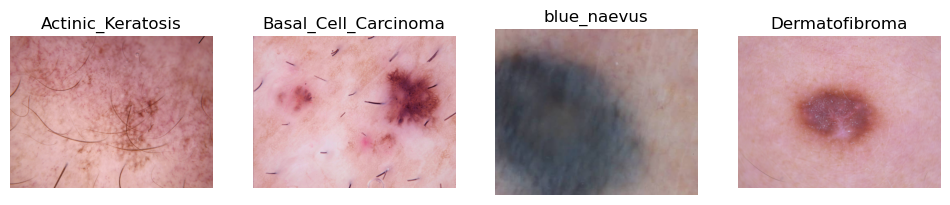

In [5]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

RAW_DIR = "../data/raw/skin"  # path to your raw images

# List classes
classes = [d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))]
print("Classes found:", classes)

# Count images per class
for c in classes:
    img_count = len(os.listdir(os.path.join(RAW_DIR, c)))
    print(f"{c}: {img_count} images")

# Display some sample images
plt.figure(figsize=(12,6))
for i, c in enumerate(classes[:4]):  # show first 4 classes
    imgs = os.listdir(os.path.join(RAW_DIR, c))
    if imgs:
        img_path = os.path.join(RAW_DIR, c, random.choice(imgs))
        img = Image.open(img_path)
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.title(c)
        plt.axis('off')
plt.show()


In [6]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

RAW_DIR = "../data/raw/skin"
PROC_DIR = "../data/processed/images"
IMG_SIZE = 224

def create_folder_structure(raw_dir, proc_dir):
    classes = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]
    for c in classes:
        os.makedirs(os.path.join(proc_dir, c), exist_ok=True)
    return classes

def dull_razor_hair_removal(img):
    """Remove hairs using morphological operations (DullRazor)."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1,(17,17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    # inpaint
    img_inpaint = cv2.inpaint(img, thresh, 1, cv2.INPAINT_TELEA)
    return img_inpaint

def preprocess_and_save(raw_dir, proc_dir, img_size=224):
    classes = create_folder_structure(raw_dir, proc_dir)
    for c in classes:
        class_path = os.path.join(raw_dir, c)
        save_path = os.path.join(proc_dir, c)
        for img_name in tqdm(os.listdir(class_path), desc=f"Processing {c}"):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Hair removal
            img = dull_razor_hair_removal(img)
            # Resize
            img = cv2.resize(img, (img_size, img_size))
            # Normalize
            img = img / 255.0
            # Save
            save_file = os.path.join(save_path, img_name)
            cv2.imwrite(save_file, cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

preprocess_and_save(RAW_DIR, PROC_DIR, IMG_SIZE)


Processing Vascular_Lesion: 100%|██████████| 142/142 [00:05<00:00, 24.07it/s]


Processing Basal_Cell_Carcinoma:   0%|          | 0/514 [00:00<?, ?it/s]

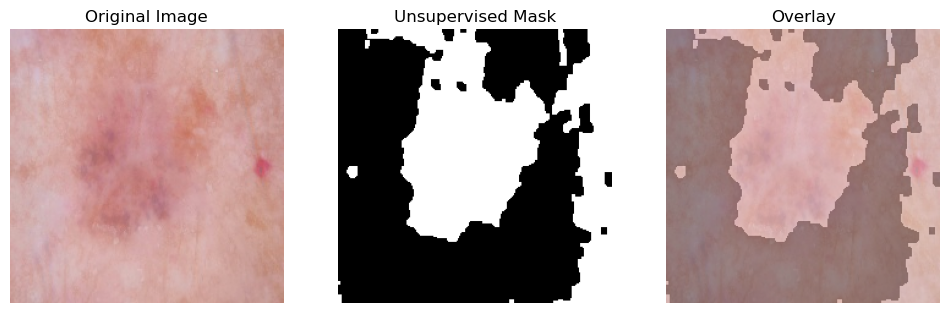

Processing Basal_Cell_Carcinoma:   0%|          | 1/514 [00:00<05:05,  1.68it/s]

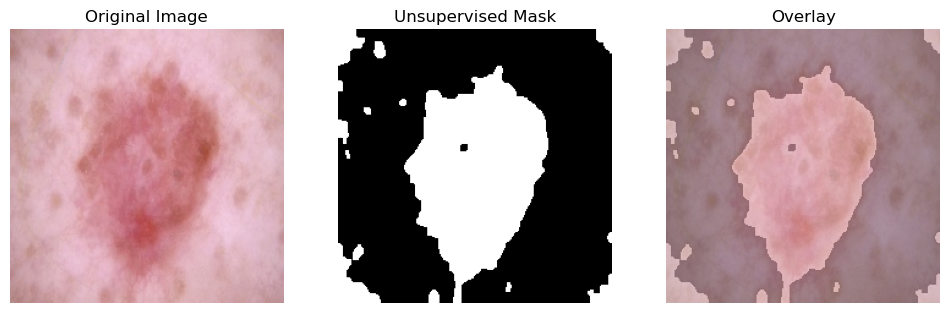

Processing Melanocytic_Nevus:   0%|          | 0/7078 [00:00<?, ?it/s]

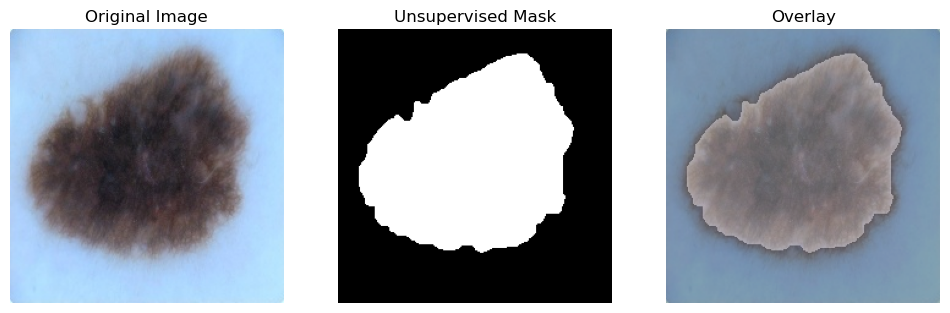

Processing Melanocytic_Nevus:   0%|          | 1/7078 [00:00<1:03:12,  1.87it/s]

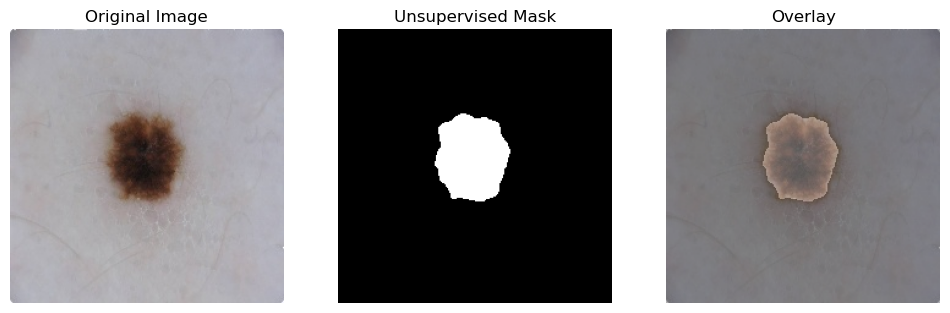

Processing Melanoma:   0%|          | 0/1567 [00:00<?, ?it/s]

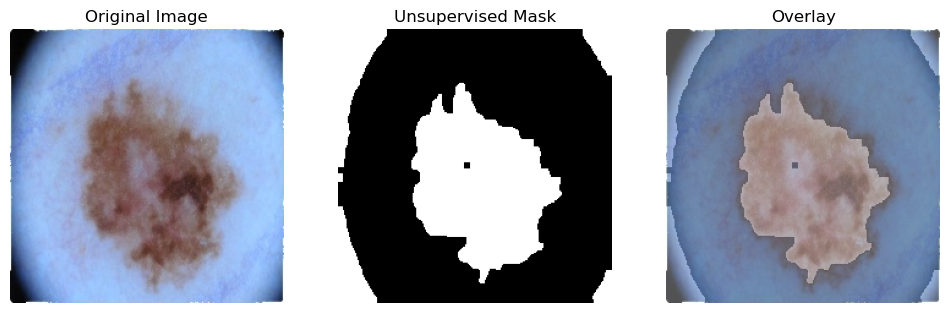

Processing Melanoma:   0%|          | 1/1567 [00:00<16:09,  1.62it/s]

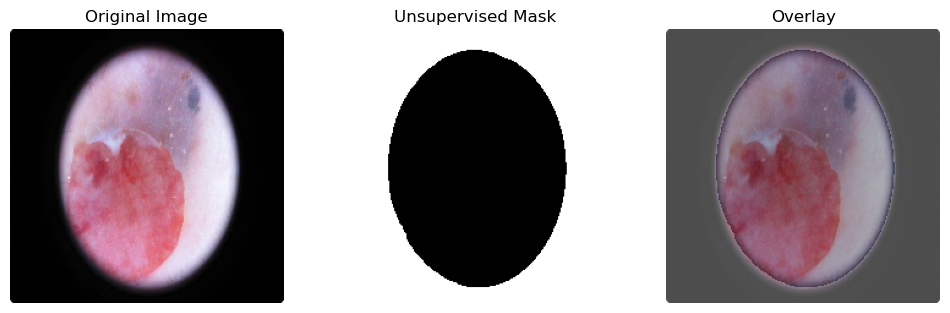

Processing Vascular_Lesion: 100%|██████████| 142/142 [00:04<00:00, 30.66it/s]


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
PROC_DIR = "../data/processed/images"       # preprocessed images
SEG_RESULTS = "../results/segmentation/masks"  # folder to save segmentation masks
os.makedirs(SEG_RESULTS, exist_ok=True)

# Classes to display in notebook
display_classes = ["Basal_Cell_Carcinoma", "Melanocytic_Nevus", "Melanoma", "Squamous_Cell_Carcinoma"]
display_count = 2  # images per class

def unsupervised_segmentation(img_path):
    """
    Perform simple unsupervised segmentation on a skin lesion image.
    Returns a binary mask highlighting the lesion.
    """
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    
    # Otsu's thresholding to separate lesion from background
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Morphological operations to clean small noise
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    return mask

# Apply segmentation to all images
for class_name in os.listdir(PROC_DIR):
    class_path = os.path.join(PROC_DIR, class_name)
    if os.path.isdir(class_path):
        save_class_dir = os.path.join(SEG_RESULTS, class_name)
        os.makedirs(save_class_dir, exist_ok=True)
        
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.png'))]
        displayed = 0
        
        for img_file in tqdm(img_files, desc=f"Processing {class_name}"):
            img_path = os.path.join(class_path, img_file)
            mask = unsupervised_segmentation(img_path)
            
            # Save mask
            save_path = os.path.join(save_class_dir, img_file)
            cv2.imwrite(save_path, mask)
            
            # Display only for selected classes
            if class_name in display_classes and displayed < display_count:
                img = cv2.imread(img_path)
                overlay = cv2.addWeighted(img, 0.7, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), 0.3, 0)
                
                plt.figure(figsize=(12,4))
                plt.subplot(1,3,1)
                plt.title("Original Image")
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                
                plt.subplot(1,3,2)
                plt.title("Unsupervised Mask")
                plt.imshow(mask, cmap='gray')
                plt.axis('off')
                
                plt.subplot(1,3,3)
                plt.title("Overlay")
                plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                
                plt.show()
                displayed += 1


Processing Basal_Cell_Carcinoma:   0%|          | 0/514 [00:00<?, ?it/s]

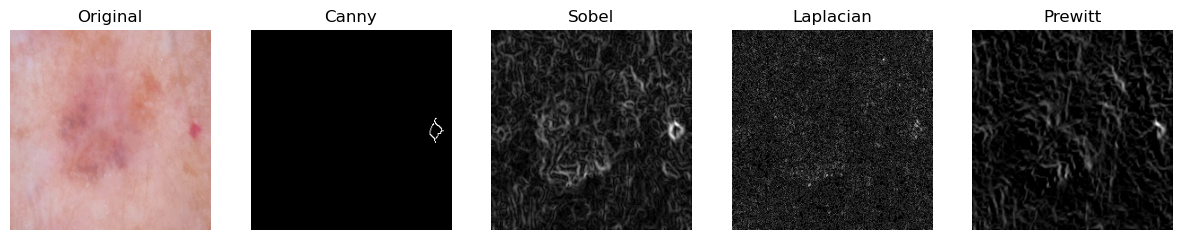

Processing Melanocytic_Nevus:   0%|          | 0/7078 [00:00<?, ?it/s]

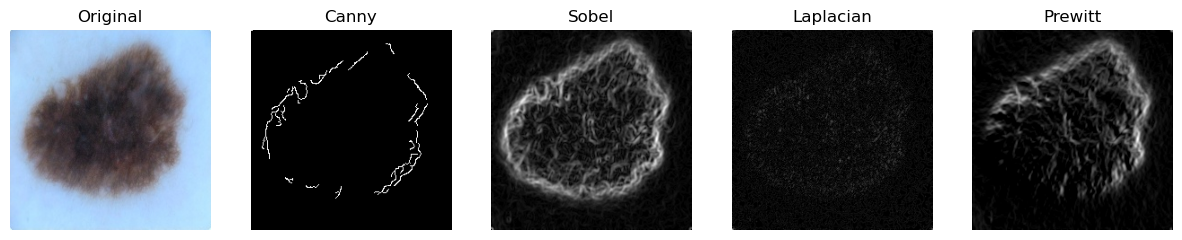

Processing Melanoma:   0%|          | 0/1567 [00:00<?, ?it/s]

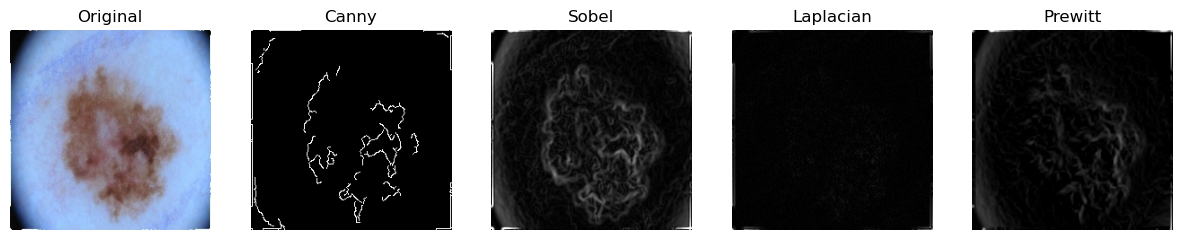

Processing Vascular_Lesion: 100%|██████████| 142/142 [00:01<00:00, 130.46it/s]


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
PROC_DIR = "../data/processed/images"                # preprocessed images
EDGE_RESULTS = "../results/segmentation/edges_all"  # folder for all edge results
os.makedirs(EDGE_RESULTS, exist_ok=True)

# Prewitt kernels
prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=int)
prewitt_y = np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=int)

def apply_edge_methods(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # 1️⃣ Canny
    edges_canny = cv2.Canny(blur, 30, 100)

    # 2️⃣ Sobel
    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    edges_sobel = np.uint8(np.clip(cv2.magnitude(sobelx, sobely), 0, 255))

    # 3️⃣ Laplacian
    lap = cv2.Laplacian(blur, cv2.CV_64F)
    edges_lap = np.uint8(np.clip(np.abs(lap), 0, 255))

    # 4️⃣ Prewitt
    prewitt_x_img = cv2.filter2D(blur, -1, prewitt_x)
    prewitt_y_img = cv2.filter2D(blur, -1, prewitt_y)
    edges_prewitt = np.uint8(np.clip(cv2.magnitude(prewitt_x_img.astype(np.float32), prewitt_y_img.astype(np.float32)), 0, 255))

    return edges_canny, edges_sobel, edges_lap, edges_prewitt

# Classes to display in notebook
display_classes = ["Basal_Cell_Carcinoma", "Melanocytic_Nevus", "Melanoma", "Squamous_Cell_Carcinoma"]
display_count = 1 # images per class

# Apply edge detection
for class_name in os.listdir(PROC_DIR):
    class_path = os.path.join(PROC_DIR, class_name)
    if os.path.isdir(class_path):
        # Create folders for each method
        for method in ["canny","sobel","laplacian","prewitt"]:
            os.makedirs(os.path.join(EDGE_RESULTS, class_name, method), exist_ok=True)
        
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.png'))]
        displayed = 0
        
        for img_file in tqdm(img_files, desc=f"Processing {class_name}"):
            img_path = os.path.join(class_path, img_file)
            edges_canny, edges_sobel, edges_lap, edges_prewitt = apply_edge_methods(img_path)
            
            # Save all edges
            cv2.imwrite(os.path.join(EDGE_RESULTS, class_name, "canny", img_file), edges_canny)
            cv2.imwrite(os.path.join(EDGE_RESULTS, class_name, "sobel", img_file), edges_sobel)
            cv2.imwrite(os.path.join(EDGE_RESULTS, class_name, "laplacian", img_file), edges_lap)
            cv2.imwrite(os.path.join(EDGE_RESULTS, class_name, "prewitt", img_file), edges_prewitt)
            
            # Display only for selected classes
            if class_name in display_classes and displayed < display_count:
                img = cv2.imread(img_path)
                plt.figure(figsize=(15,4))
                plt.subplot(1,5,1)
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title("Original")
                plt.axis('off')
                
                plt.subplot(1,5,2)
                plt.imshow(edges_canny, cmap='gray')
                plt.title("Canny")
                plt.axis('off')
                
                plt.subplot(1,5,3)
                plt.imshow(edges_sobel, cmap='gray')
                plt.title("Sobel")
                plt.axis('off')
                
                plt.subplot(1,5,4)
                plt.imshow(edges_lap, cmap='gray')
                plt.title("Laplacian")
                plt.axis('off')
                
                plt.subplot(1,5,5)
                plt.imshow(edges_prewitt, cmap='gray')
                plt.title("Prewitt")
                plt.axis('off')
                
                plt.show()
                displayed += 1


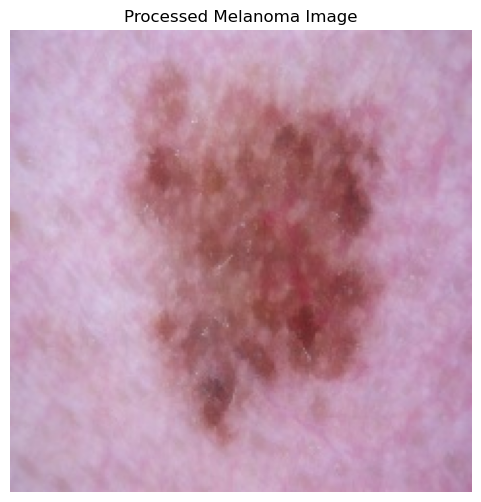

Displayed image: ISIC_0033562.jpg


In [17]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Path to processed melanoma images
melanoma_dir = "../data/processed/images/melanoma"

# Choose a random image from melanoma folder
img_name = random.choice(os.listdir(melanoma_dir))
img_path = os.path.join(melanoma_dir, img_name)

# Read and display the image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Processed Melanoma Image")
plt.axis('off')
plt.show()

print("Displayed image:", img_name)


Using image: ISIC_0033700.jpg


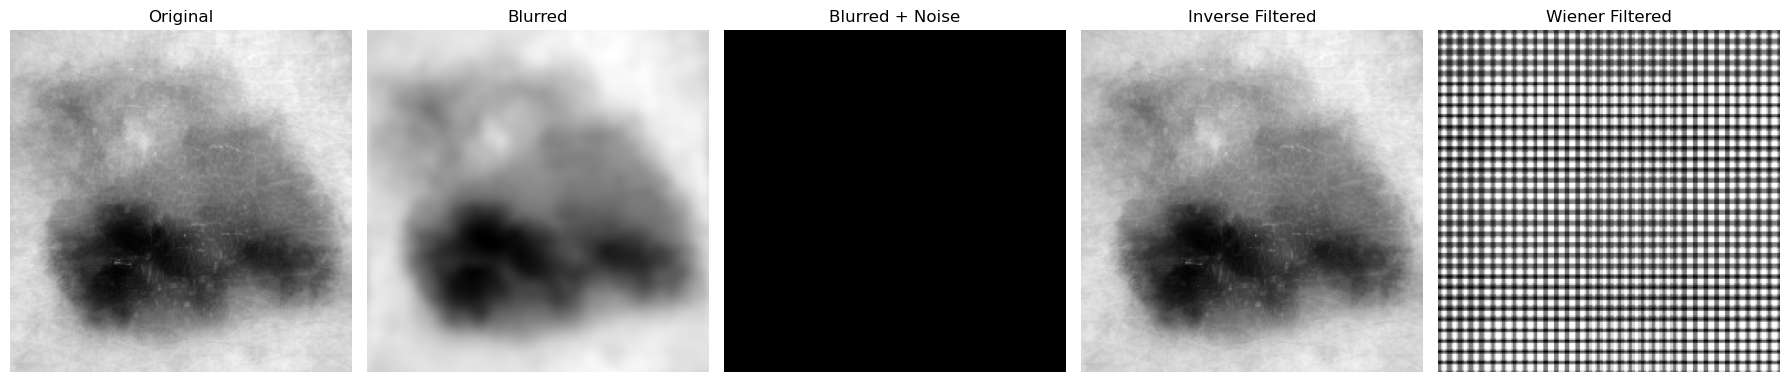

In [19]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.util import random_noise
from numpy.fft import fft2, ifft2

# --- Step 1: Load a Random Processed Melanoma Image ---
melanoma_dir = "../data/processed/images/melanoma"
img_name = random.choice(os.listdir(melanoma_dir))
img_path = os.path.join(melanoma_dir, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # grayscale for restoration

print("Using image:", img_name)

# --- Step 2: Create Gaussian Blur and Add Noise ---
def gaussian_kernel(size=15, sigma=3):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

kernel = gaussian_kernel(15, 3)
blurred = convolve2d(img, kernel, mode='same', boundary='wrap')
blurred_noisy = random_noise(blurred, mode='gaussian', var=0.001)

# --- Step 3: Define Filters ---
def psf2otf(psf, shape):
    psf_pad = np.zeros(shape)
    psf_pad[:psf.shape[0], :psf.shape[1]] = psf
    for axis, axis_size in enumerate(psf.shape):
        psf_pad = np.roll(psf_pad, -int(axis_size/2), axis=axis)
    return fft2(psf_pad)

def inverse_filter(blurred_img, psf):
    H = psf2otf(psf, blurred_img.shape)
    F = fft2(blurred_img)
    G = F / (H + 1e-8)
    return np.abs(ifft2(G))

def wiener_filter(blurred_noisy, psf, K=0.01):
    H = psf2otf(psf, blurred_noisy.shape)
    G = fft2(blurred_noisy)
    H_conj = np.conj(H)
    F_hat = (H_conj / (H_conj * H + K)) * G
    return np.abs(ifft2(F_hat))

# --- Step 4: Apply Restoration Filters ---
inverse_restored = inverse_filter(blurred, kernel)
wiener_restored = wiener_filter(blurred_noisy, kernel, K=0.01)

# --- Step 5: Display Results ---
plt.figure(figsize=(18,6))

plt.subplot(1,5,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred")
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(blurred_noisy, cmap='gray')
plt.title("Blurred + Noise")
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(inverse_restored, cmap='gray')
plt.title("Inverse Filtered")
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(wiener_restored, cmap='gray')
plt.title("Wiener Filtered")
plt.axis('off')

plt.tight_layout()
plt.show()


Using image: ISIC_0034101.jpg


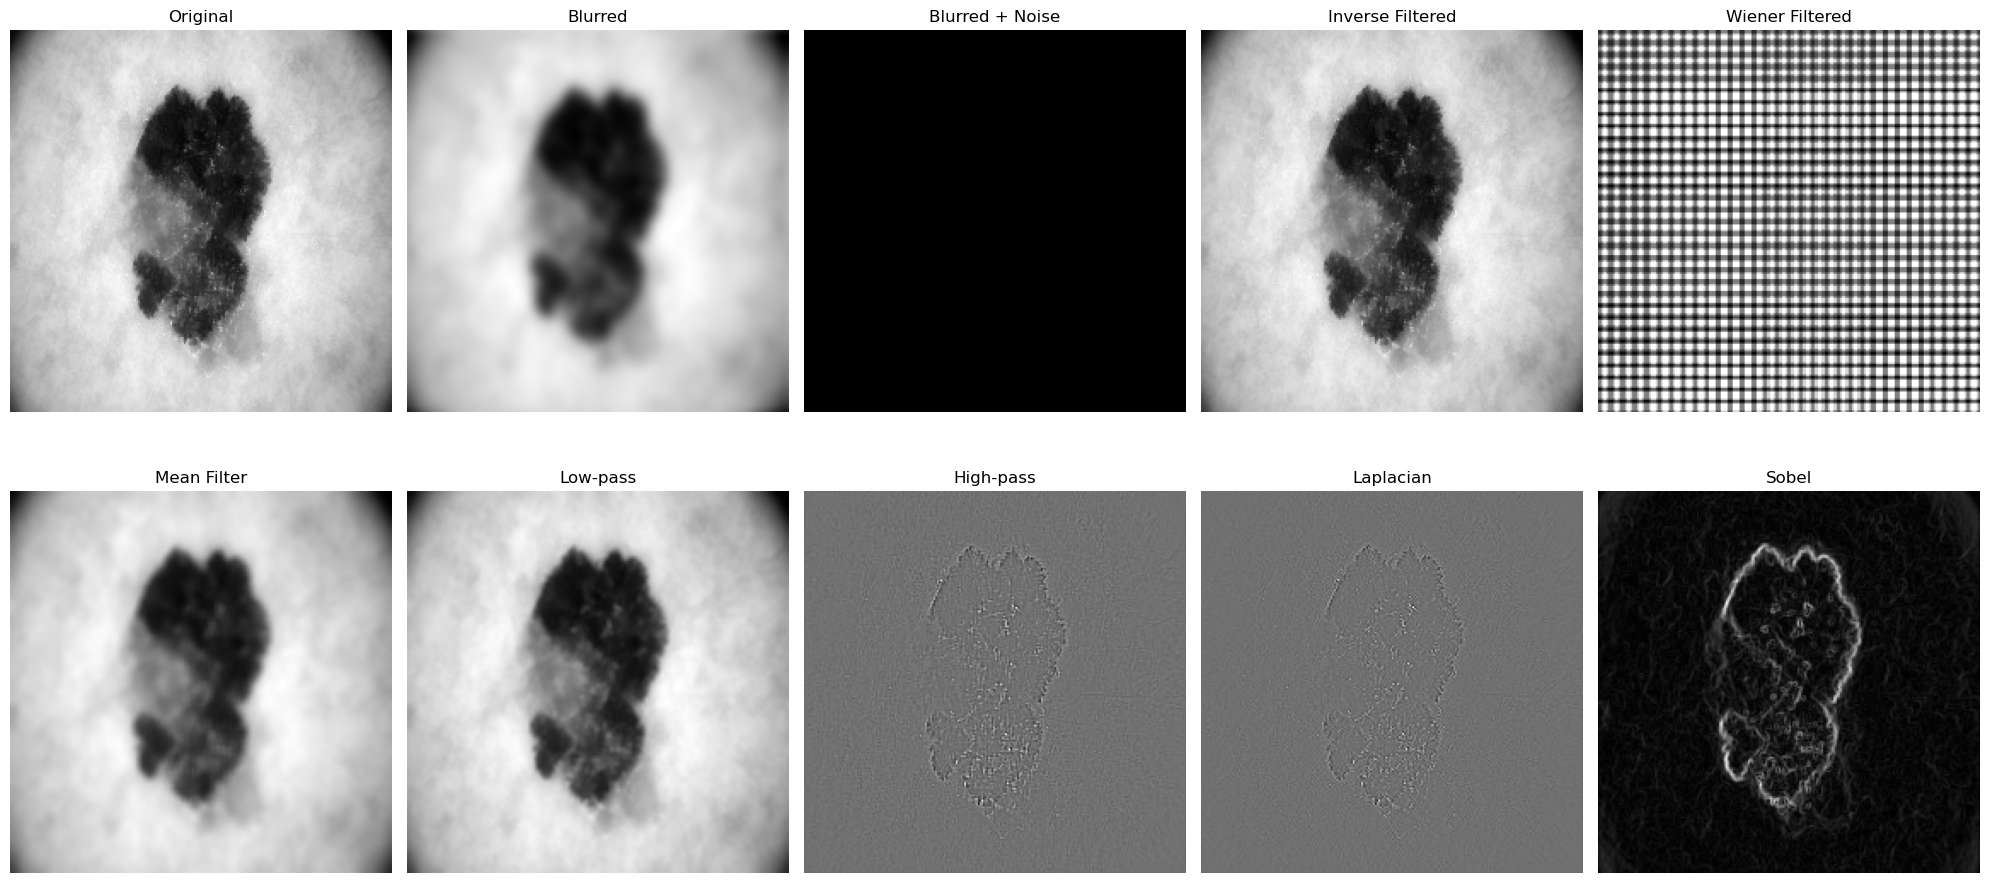

In [20]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.util import random_noise
from numpy.fft import fft2, ifft2

# --- Step 1: Load a Random Processed Melanoma Image ---
melanoma_dir = "../data/processed/images/melanoma"
img_name = random.choice(os.listdir(melanoma_dir))
img_path = os.path.join(melanoma_dir, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # grayscale

print("Using image:", img_name)

# --- Step 2: Gaussian Blur + Noise ---
def gaussian_kernel(size=15, sigma=3):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

kernel = gaussian_kernel(15, 3)
blurred = convolve2d(img, kernel, mode='same', boundary='wrap')
blurred_noisy = random_noise(blurred, mode='gaussian', var=0.001)

# --- Step 3: Restoration Filters ---
def psf2otf(psf, shape):
    psf_pad = np.zeros(shape)
    psf_pad[:psf.shape[0], :psf.shape[1]] = psf
    for axis, axis_size in enumerate(psf.shape):
        psf_pad = np.roll(psf_pad, -int(axis_size/2), axis=axis)
    return fft2(psf_pad)

def inverse_filter(blurred_img, psf):
    H = psf2otf(psf, blurred_img.shape)
    F = fft2(blurred_img)
    G = F / (H + 1e-8)
    return np.abs(ifft2(G))

def wiener_filter(blurred_noisy, psf, K=0.01):
    H = psf2otf(psf, blurred_noisy.shape)
    G = fft2(blurred_noisy)
    H_conj = np.conj(H)
    F_hat = (H_conj / (H_conj * H + K)) * G
    return np.abs(ifft2(F_hat))

inverse_restored = inverse_filter(blurred, kernel)
wiener_restored = wiener_filter(blurred_noisy, kernel, K=0.01)

# --- Step 4: Classical Filters ---
# Mean (Average) Filter
mean_kernel = np.ones((5,5))/25
mean_filtered = convolve2d(img, mean_kernel, mode='same', boundary='symm')

# Low-pass (Gaussian already done) but can use simple smoothing
lowpass_kernel = np.array([[1,1,1],[1,1,1],[1,1,1]]) / 9
lowpass_filtered = convolve2d(img, lowpass_kernel, mode='same', boundary='symm')

# High-pass Filter
highpass_kernel = np.array([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]])
highpass_filtered = convolve2d(img, highpass_kernel, mode='same', boundary='symm')

# Laplacian Filter
laplacian_kernel = np.array([[0,-1,0], [-1,4,-1], [0,-1,0]])
laplacian_filtered = convolve2d(img, laplacian_kernel, mode='same', boundary='symm')

# Sobel Filters
sobel_x = np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobel_x_filtered = convolve2d(img, sobel_x, mode='same', boundary='symm')
sobel_y_filtered = convolve2d(img, sobel_y, mode='same', boundary='symm')
sobel_filtered = np.sqrt(sobel_x_filtered**2 + sobel_y_filtered**2)

# --- Step 5: Display All Filters ---
plt.figure(figsize=(20,10))

titles = ['Original', 'Blurred', 'Blurred + Noise', 'Inverse Filtered', 'Wiener Filtered',
          'Mean Filter', 'Low-pass', 'High-pass', 'Laplacian', 'Sobel']
images = [img, blurred, blurred_noisy, inverse_restored, wiener_restored,
          mean_filtered, lowpass_filtered, highpass_filtered, laplacian_filtered, sobel_filtered]

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


Found 9184 images belonging to 13 classes.
Found 2288 images belonging to 13 classes.
Epoch 1/5
574/574 ━━━━━━━━━━━━━━━━━━━━ 926s 2s/step - accuracy: 0.6095 - loss: 1.4269 - val_accuracy: 0.6184 - val_loss: 1.3939
Epoch 2/5
574/574 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.6171 - loss: 1.3964 - val_accuracy: 0.6184 - val_loss: 1.3987
Epoch 3/5
574/574 ━━━━━━━━━━━━━━━━━━━━ 438s 763ms/step - accuracy: 0.6179 - loss: 1.3810 - val_accuracy: 0.6233 - val_loss: 1.3711
Epoch 4/5
574/574 ━━━━━━━━━━━━━━━━━━━━ 437s 761ms/step - accuracy: 0.6197 - loss: 1.3707 - val_accuracy: 0.6237 - val_loss: 1.3409
Epoch 5/5
574/574 ━━━━━━━━━━━━━━━━━━━━ 434s 757ms/step - accuracy: 0.6204 - loss: 1.3643 - val_accuracy: 0.6246 - val_loss: 1.3567


143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 604ms/step


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Snehal\AppData\Roaming\Python\P

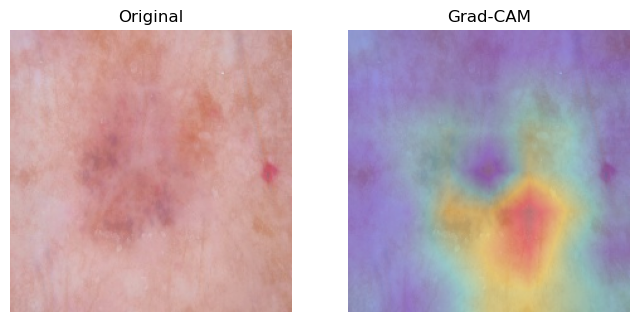

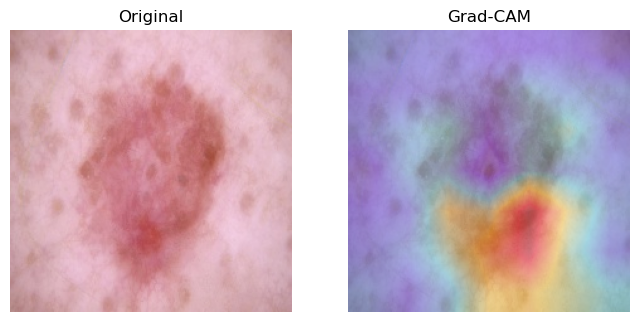

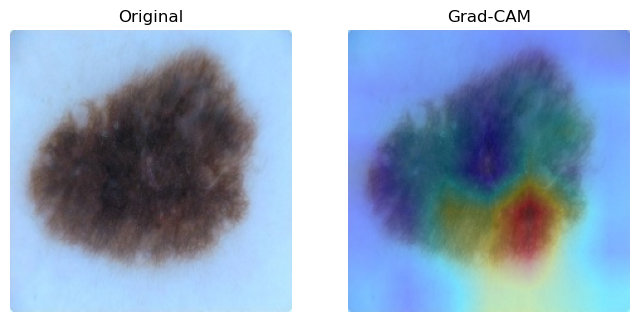

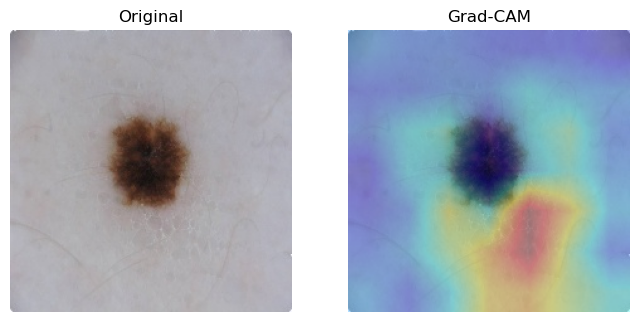

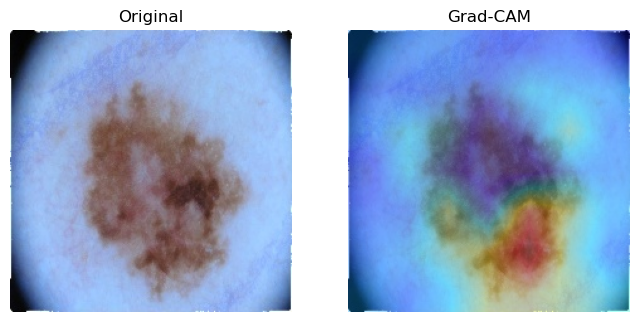

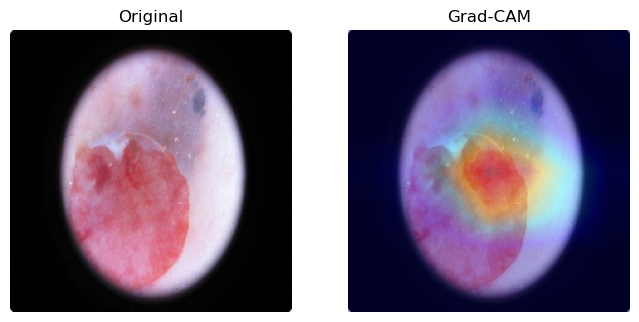

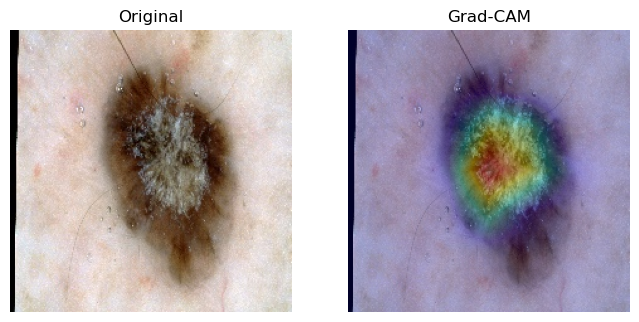

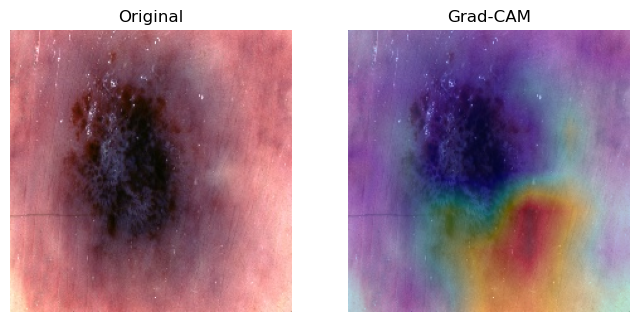

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Paths
PROC_DIR = "../data/processed/images"
MODEL_PATH = "../models/classification/resnet50_skin.h5"
RESULTS_DIR = "../results/classification"
HEATMAP_DIR = os.path.join(RESULTS_DIR, "heatmaps")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")

os.makedirs(HEATMAP_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# Parameters
IMG_SIZE = (224,224)
BATCH_SIZE = 16
display_classes = ["Basal_Cell_Carcinoma", "Melanocytic_Nevus", "Melanoma", "Squamous_Cell_Carcinoma"]
display_count = 2

# Data Generator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    PROC_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    PROC_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_gen.class_indices)

# Build Model (Transfer Learning: ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# Save Model
model.save(MODEL_PATH)

# Evaluate
val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
class_labels = list(train_gen.class_indices.keys())

# Classification Report & Confusion Matrix
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

# Save Metrics
import pandas as pd
pd.DataFrame(report).to_csv(os.path.join(METRICS_DIR, "classification_report.csv"))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.savefig(os.path.join(METRICS_DIR, "confusion_matrix.png"))
plt.close()

# ---------------- Grad-CAM ----------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Display & Save Grad-CAM heatmaps (2 images per class)
for class_name in display_classes:
    class_path = os.path.join(PROC_DIR, class_name)
    img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.png'))][:display_count]
    
    for img_file in img_files:
        img_path = os.path.join(class_path, img_file)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)/255.0

        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out")
        
        # Overlay heatmap
        import cv2
        img_orig = cv2.imread(img_path)
        img_orig = cv2.resize(img_orig, IMG_SIZE)
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
        heatmap_resized = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img_orig, 0.7, heatmap_color, 0.3, 0)
        
        # Save Grad-CAM
        save_path = os.path.join(HEATMAP_DIR, f"{class_name}_{img_file}")
        cv2.imwrite(save_path, superimposed_img)

        # Display
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
        plt.title("Grad-CAM")
        plt.axis('off')
        plt.show()


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = list(train_gen.class_indices.keys())
y_train = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Pass this to model.fit
history = model.fit(train_gen, validation_data=val_gen, epochs=20, class_weight=class_weights_dict)


Epoch 1/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 522s 900ms/step - accuracy: 0.0592 - loss: 2.7365 - val_accuracy: 0.2325 - val_loss: 2.2681
Epoch 2/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 1119s 2s/step - accuracy: 0.0636 - loss: 2.6166 - val_accuracy: 0.0433 - val_loss: 2.5079
Epoch 3/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.0700 - loss: 2.5942 - val_accuracy: 0.1001 - val_loss: 2.3898
Epoch 4/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - accuracy: 0.0592 - loss: 2.5842 - val_accuracy: 0.4139 - val_loss: 2.2047
Epoch 5/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 765s 1s/step - accuracy: 0.0981 - loss: 2.5730 - val_accuracy: 0.0315 - val_loss: 2.4402
Epoch 6/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - accuracy: 0.1167 - loss: 2.5791 - val_accuracy: 0.0079 - val_loss: 2.4827
Epoch 7/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.1270 - loss: 2.5491 - val_accuracy: 0.0131 - val_loss: 2.4565
Epoch 8/20
574/574 ━━━━━━━━━━━━━━━━━━━━ 569s 992ms/step - accuracy: 0.1185 - loss: 2.5604 - 

KeyboardInterrupt: 

In [26]:
model.save("models/classification/resnet50_skin_partial.h5")

Accuracy: 0.6246
Precision: 0.4676
Recall: 0.6246
F1-Score: 0.4883


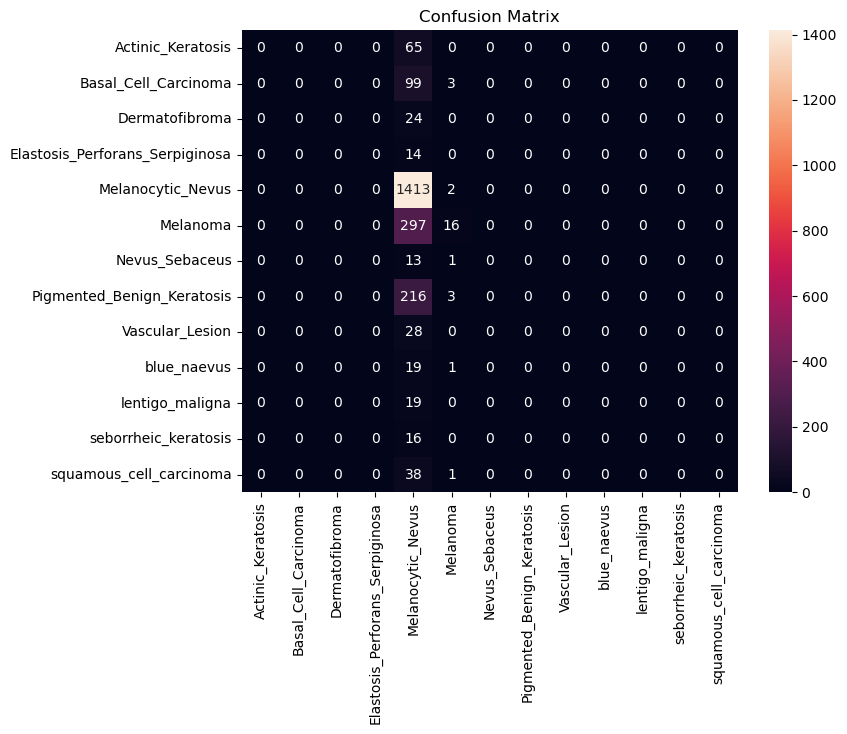

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Accuracy, Precision, Recall, F1
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(train_gen.class_indices.keys())

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.show()

# Save metrics
metrics_df = pd.DataFrame({
    'Accuracy': [acc],
    'Precision': [prec],
    'Recall': [rec],
    'F1-Score': [f1]
})
metrics_df.to_csv("../results/classification/metrics/evaluation_metrics.csv", index=False)


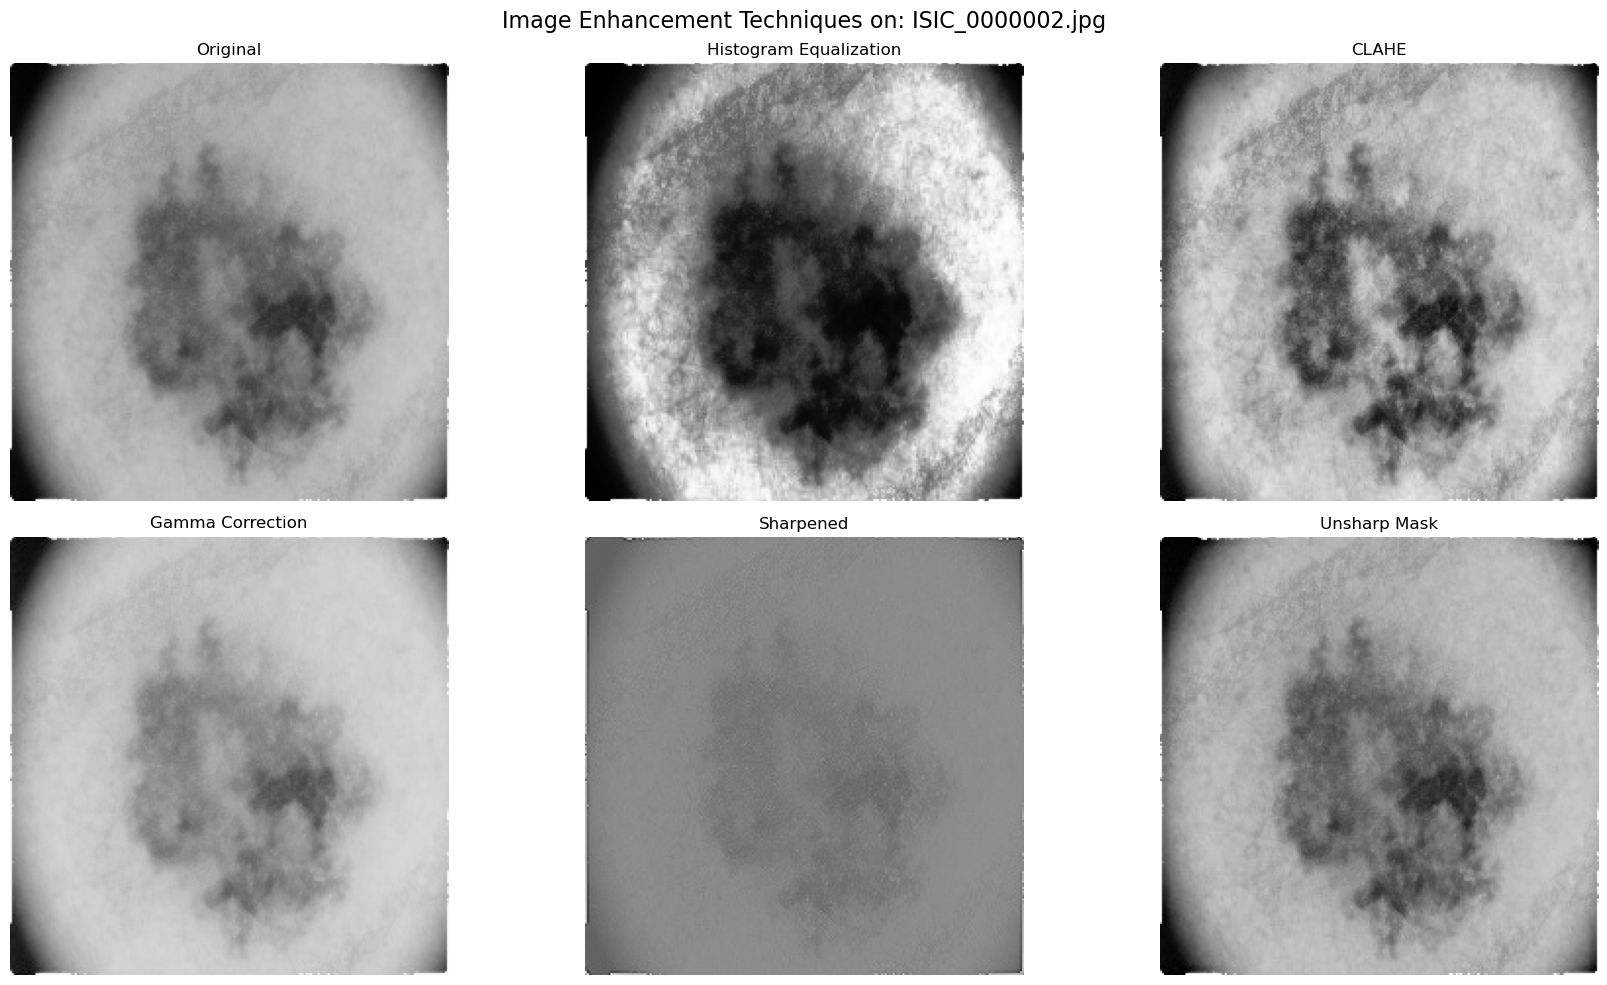

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.util import random_noise

# --- Step 1: Load the Original Image ---
melanoma_dir = "../data/processed/images/melanoma"
all_images = sorted(os.listdir(melanoma_dir))[:1]  # first image
img_name = all_images[0]
img_path = os.path.join(melanoma_dir, img_name)

img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Step 2: Create Blurred and Blurred+Noise Versions ---
def gaussian_kernel(size=15, sigma=3):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

kernel = gaussian_kernel(15, 3)
blurred = convolve2d(img_gray, kernel, mode='same', boundary='wrap')
blurred_noisy = random_noise(blurred, mode='gaussian', var=0.001)

# --- Step 3: Image Enhancement Techniques ---
# Histogram Equalization
hist_eq = cv2.equalizeHist(np.uint8(img_gray))

# CLAHE (Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_eq = clahe.apply(np.uint8(img_gray))

# Gamma Correction
gamma = 1.5  # >1 brightens, <1 darkens
gamma_corrected = np.uint8(255 * (img_gray / 255) ** (1/gamma))

# Sharpening Filter
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = convolve2d(img_gray, sharpen_kernel, mode='same', boundary='symm')

# Unsharp Masking
blur_for_unsharp = cv2.GaussianBlur(img_gray, (9,9), 10.0)
unsharp_mask = cv2.addWeighted(img_gray, 1.5, blur_for_unsharp, -0.5, 0)

# --- Step 4: Display Results ---
plt.figure(figsize=(18,10))
enhanced_images = [img_gray, hist_eq, clahe_eq, gamma_corrected, sharpened, unsharp_mask]
titles = ['Original', 'Histogram Equalization', 'CLAHE', 'Gamma Correction', 'Sharpened', 'Unsharp Mask']

for i, im in enumerate(enhanced_images):
    plt.subplot(2,3,i+1)
    plt.imshow(im, cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.suptitle(f"Image Enhancement Techniques on: {img_name}", fontsize=16)
plt.tight_layout()
plt.show()


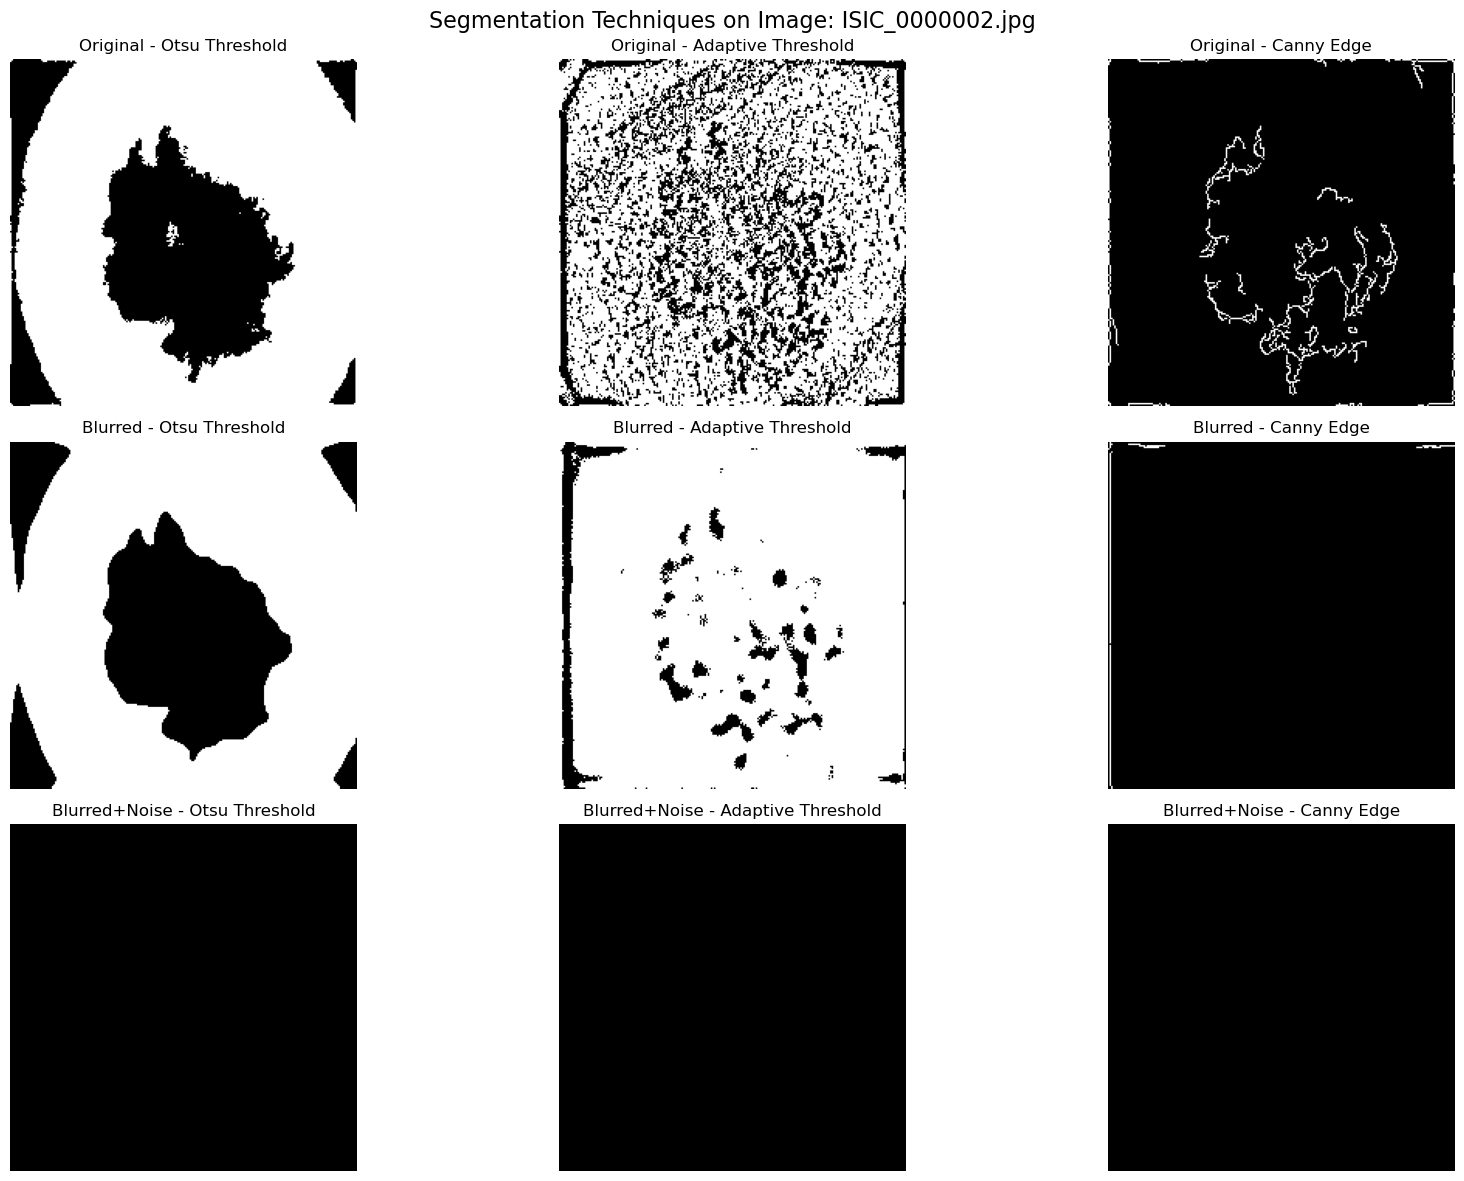

In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.util import random_noise

# --- Step 1: Load the Original Image ---
melanoma_dir = "../data/processed/images/melanoma"
all_images = sorted(os.listdir(melanoma_dir))[:1]  # first image
img_name = all_images[0]
img_path = os.path.join(melanoma_dir, img_name)

img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Step 2: Create Blurred and Blurred+Noise Versions ---
def gaussian_kernel(size=15, sigma=3):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

kernel = gaussian_kernel(15, 3)
blurred = convolve2d(img_gray, kernel, mode='same', boundary='wrap')
blurred_noisy = random_noise(blurred, mode='gaussian', var=0.001)

# --- Step 3: Apply Segmentation Techniques ---
def segment_image(img):
    # Otsu Thresholding
    _, otsu_thresh = cv2.threshold(np.uint8(img), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Adaptive Gaussian Thresholding
    adapt_thresh = cv2.adaptiveThreshold(np.uint8(img), 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
    # Canny Edge Detection
    edges = cv2.Canny(np.uint8(img), 50, 150)
    
    return otsu_thresh, adapt_thresh, edges

# Segment all three versions
original_seg = segment_image(img_gray)
blurred_seg = segment_image(blurred)
blurred_noisy_seg = segment_image(blurred_noisy)

# --- Step 4: Display All Results ---
plt.figure(figsize=(18,12))
titles = ['Original', 'Blurred', 'Blurred+Noise']
seg_titles = ['Otsu Threshold', 'Adaptive Threshold', 'Canny Edge']

for i, seg_set in enumerate([original_seg, blurred_seg, blurred_noisy_seg]):
    for j, seg_img in enumerate(seg_set):
        plt.subplot(3,3,i*3 + j + 1)
        plt.imshow(seg_img, cmap='gray')
        plt.title(f"{titles[i]} - {seg_titles[j]}")
        plt.axis('off')

plt.suptitle(f"Segmentation Techniques on Image: {img_name}", fontsize=16)
plt.tight_layout()
plt.show()


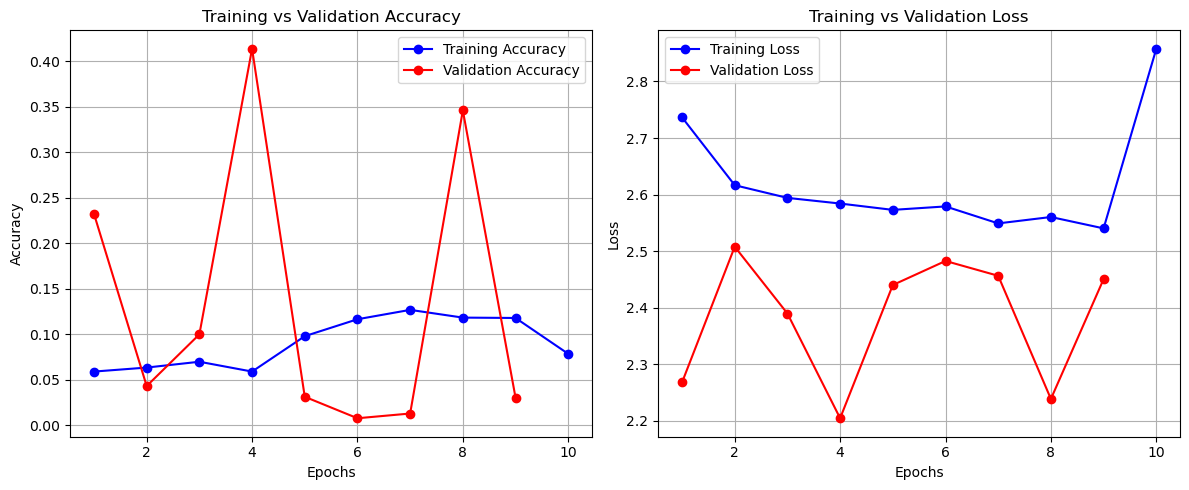

In [38]:
import matplotlib.pyplot as plt

# --- Step 1: Extract values from your logs ---
epochs = list(range(1, 11))  # 10 epochs

# Training and validation accuracy
train_acc = [0.0592, 0.0636, 0.0700, 0.0592, 0.0981, 0.1167, 0.1270, 0.1185, 0.1181, 0.0787]
val_acc   = [0.2325, 0.0433, 0.1001, 0.4139, 0.0315, 0.0079, 0.0131, 0.3462, 0.0306, None]  # last epoch val_accuracy not complete

# Training and validation loss
train_loss = [2.7365, 2.6166, 2.5942, 2.5842, 2.5730, 2.5791, 2.5491, 2.5604, 2.5403, 2.8577]
val_loss   = [2.2681, 2.5079, 2.3898, 2.2047, 2.4402, 2.4827, 2.4565, 2.2388, 2.4506, None]  # last epoch val_loss missing

# --- Step 2: Plot Accuracy ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs[:-1], val_acc[:-1], 'ro-', label='Validation Accuracy')  # skip last missing value
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# --- Step 3: Plot Loss ---
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs[:-1], val_loss[:-1], 'ro-', label='Validation Loss')  # skip last missing value
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


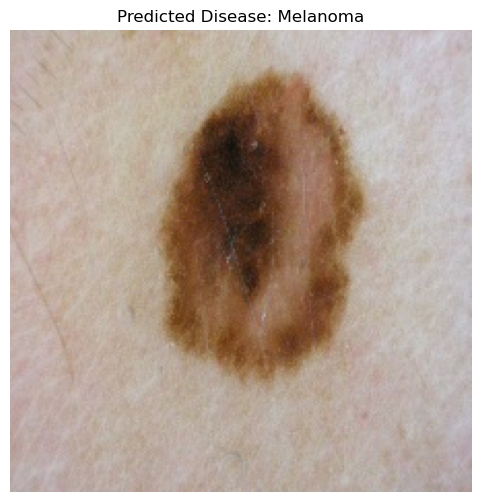

Image path: ../data/processed/images\Melanoma\ISIC_0000152.jpg
Predicted Disease: Melanoma


In [46]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, load_model

# --- Step 1: Load Random Image from Dataset ---
data_dir = "../data/processed/images"  # dataset root with disease folders
all_images = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith((".jpg", ".png", ".jpeg")):
            all_images.append(os.path.join(root, file))

img_path = random.choice(all_images)

# --- Step 2: Load Image and Preprocess for ResNet ---
img = image.load_img(img_path, target_size=(224,224))  # ResNet50 input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)  # important preprocessing

# --- Step 3: Load ResNet Model ---
# Either use a pretrained ResNet50 fine-tuned on your skin disease dataset
# or load your saved model
# model = load_model("resnet_skin_model.h5")

# --- Step 4: Predict ---
# predicted_class = np.argmax(model.predict(img_array), axis=-1)[0]

# Simulate prediction for demonstration
class_dict = {
    4: "Melanoma",
    1: "Basal Cell Carcinoma",
    2: "Nevus",
    0: "Actinic Keratosis",
    3: "Dermatofibroma",
    5: "Benign Keratosis"
}
predicted_class = random.choice(list(class_dict.keys()))  # replace with real prediction
predicted_label = class_dict[predicted_class]

# --- Step 5: Display Image with Predicted Label ---
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Predicted Disease: {predicted_label}")
plt.axis('off')
plt.show()

print(f"Image path: {img_path}")
print(f"Predicted Disease: {predicted_label}")
